# KBO 2022~2026 데이터 전처리 & 가을야구 진출 예측
**모델**: Logistic + Random Forest + Gradient Boosting 앙상블 | **기준일**: 2026-04-24


## CELL 1 · 라이브러리

In [1]:
# !pip install pandas numpy scikit-learn matplotlib seaborn requests beautifulsoup4 schedule
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, platform
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 한글 폰트
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    try:
        fp = [f.fname for f in fm.fontManager.ttflist if 'Nanum' in f.name][0]
        plt.rcParams['font.family'] = fm.FontProperties(fname=fp).get_name()
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print("✅ 라이브러리 OK")


✅ 라이브러리 OK


## CELL 2 · 전처리 유틸리티 함수

In [2]:
TEAM_NAME_MAP = {
    "SK":"SSG","SK와이번스":"SSG","SSG랜더스":"SSG",
    "KIA타이거즈":"KIA","LG트윈스":"LG","KT위즈":"KT",
    "두산베어스":"두산","삼성라이온즈":"삼성","롯데자이언츠":"롯데",
    "NC다이노스":"NC","키움히어로즈":"키움","한화이글스":"한화",
}

def read_csv_safe(path):
    for enc in ['utf-8','cp949','euc-kr']:
        try: return pd.read_csv(path, encoding=enc)
        except: continue
    raise ValueError(f"읽기 실패: {path}")

def normalize_team(name):
    return TEAM_NAME_MAP.get(str(name).strip(), str(name).strip())

def parse_ip(s):
    s = str(s).strip()
    if s in ['-','','nan']: return np.nan
    if '/' in s:
        parts = s.split(); w = int(parts[0]) if len(parts)>1 else 0
        n,d = parts[-1].split('/'); return round(w+int(n)/int(d), 4)
    try: return float(s)
    except: return np.nan

def parse_dash(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].replace('-', np.nan), errors='coerce')
    return df

def parse_record(s): return s.str.extract(r'(\d+)-(\d+)-(\d+)').astype(float)
def parse_r10(s):    return s.str.extract(r'(\d+)승(\d+)무(\d+)패').astype(float)

def bat_drv(df):
    if 'HR' in df.columns and 'AB' in df.columns:
        df['HR/AB'] = (df['HR']/df['AB']).round(4)
    if all(c in df.columns for c in ['H','HR','AB','SO','SF']):
        df['BABIP'] = ((df['H']-df['HR'])/(df['AB']-df['SO']-df['HR']+df['SF'])).round(3)
    return df

def pit_drv(df):
    if all(c in df.columns for c in ['SO','IP','BB','HR']):
        df['K/9']     = (df['SO']/df['IP']*9).round(2)
        df['BB/9']    = (df['BB']/df['IP']*9).round(2)
        df['HR/9']    = (df['HR']/df['IP']*9).round(2)
        df['K/BB']    = (df['SO']/df['BB'].replace(0,np.nan)).round(2)
        df['FIP_raw'] = ((13*df['HR']+3*df['BB']-2*df['SO'])/df['IP']).round(3)
    return df

print("✅ 유틸리티 함수 OK")


✅ 유틸리티 함수 OK


## CELL 3 · 카테고리별 전처리 함수

In [3]:
def f_bat_b(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df=parse_dash(df,['AVG','G','PA','AB','R','H','2B','3B','HR','TB','RBI','SAC','SF'])
    df=bat_drv(df)
    thr = int(22*3.1) if y==2026 else 450
    df['규정타석_충족']=df['PA']>=thr; df['시즌진행중']=(y==2026); return df

def f_bat_d(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    return parse_dash(df,['AVG','XBH','GO','AO','GO/AO','GW RBI','BB/K','P/PA','ISOP','XR','GPA'])

def f_pit_b(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df['IP']=df['IP'].apply(parse_ip)
    df=parse_dash(df,['ERA','G','W','L','SV','HLD','WPCT','H','HR','BB','HBP','SO','R','ER','WHIP'])
    df=pit_drv(df); thr=22 if y==2026 else 144
    df['규정이닝_충족']=df['IP']>=thr; df['시즌진행중']=(y==2026); return df

def f_pit_d(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    return parse_dash(df,['ERA','GS','Wgs','Wgr','GF','SVO','TS','GDP','GO','AO','GO/AO'])

def f_fld(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df['IP']=df['IP'].apply(parse_ip)
    df=parse_dash(df,['G','GS','E','PKO','PO','A','DP','FPCT','PB','SB','CS'])
    df['CS%']=pd.to_numeric(df['CS%'].replace('-',np.nan),errors='coerce'); return df

def f_run(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df=parse_dash(df,['G','SBA','SB','CS','SB%','OOB','PKO'])
    df['SB%_calc']=(df['SB']/df['SBA'].replace(0,np.nan)*100).round(1); return df

def f_trk(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df=parse_dash(df,['순위','경기','승','패','무','승률','게임차'])
    h=parse_record(df['홈']);   h.columns=['홈승','홈무','홈패']
    v=parse_record(df['방문']); v.columns=['원정승','원정무','원정패']
    r=parse_r10(df['최근10경기']); r.columns=['최근승','최근무','최근패']
    df=pd.concat([df.drop(columns=['홈','방문','최근10경기','연속']),h,v,r],axis=1)
    df['홈승률']=(df['홈승']/(df['홈승']+df['홈패'])).round(3)
    df['원정승률']=(df['원정승']/(df['원정승']+df['원정패'])).round(3)
    df['홈_원정_승률차']=(df['홈승률']-df['원정승률']).round(3)
    df['시즌진행중']=(y==2026); return df

def f_dly(df, y):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    df['날짜']=pd.to_datetime(df['날짜'].astype(str),format='%Y%m%d')
    df['월']=df['날짜'].dt.month
    df=parse_dash(df,['순위','경기','승','패','무','승률','게임차'])
    r=parse_r10(df['최근10경기']); r.columns=['최근승','최근무','최근패']
    h=parse_record(df['홈']);   h.columns=['홈승','홈무','홈패']
    v=parse_record(df['방문']); v.columns=['원정승','원정무','원정패']
    return pd.concat([df.drop(columns=['최근10경기','연속','홈','방문']),r,h,v],axis=1)

def f_tg(df, y, cat):
    df=df.copy(); df['연도']=y; df['팀명']=df['팀명'].apply(normalize_team)
    if 'IP'  in df.columns: df['IP']=df['IP'].apply(parse_ip)
    if 'CS%' in df.columns: df['CS%']=pd.to_numeric(df['CS%'].replace('-',np.nan),errors='coerce')
    skip={'팀명','연도','CS%'}
    for col in df.columns:
        if col in skip: continue
        if df[col].dtype==object:
            df[col]=pd.to_numeric(df[col].replace('-',np.nan),errors='coerce')
    if cat=='팀_투수' and all(c in df.columns for c in ['SO','IP','BB','HR']):
        df['K/9']=(df['SO']/df['IP']*9).round(2)
        df['BB/9']=(df['BB']/df['IP']*9).round(2)
        df['HR/9']=(df['HR']/df['IP']*9).round(2)
    if cat=='팀_타자':
        df['HR/G']=(df['HR']/df['G']).round(2)
        df['득점/G']=(df['R']/df['G']).round(2)
    return df

FILE_PROC_MAP = {
    '타자_기본기록':    f_bat_b,
    '타자_세부기록':    f_bat_d,
    '투수_기본기록':    f_pit_b,
    '투수_세부기록':    f_pit_d,
    '수비_기본기록':    f_fld,
    '주루_기본기록':    f_run,
    '팀_순위':          f_trk,
    '팀_일자별순위':    f_dly,
    '팀_타자_기본기록': lambda df,y: f_tg(df,y,'팀_타자'),
    '팀_투수_기본기록': lambda df,y: f_tg(df,y,'팀_투수'),
    '팀_수비_기본기록': lambda df,y: f_tg(df,y,'팀_수비'),
    '팀_주루_기본기록': lambda df,y: f_tg(df,y,'팀_주루'),
}
print("✅ 전처리 함수 OK")


✅ 전처리 함수 OK


## CELL 4 · 데이터 로드 ← **반드시 이 셀 실행 후 키 목록 확인**

In [4]:
# ── 경로 설정 ────────────────────────────────────────────
# 아래 경로를 실제 환경에 맞게 수정하세요
PROCESSED_DIR = Path(r'C:\Users\Admin\Documents\GitHub\Ml_Baseball\dy_\kbo_clean_data\processed')   # 통합 CSV 폴더
RAW_ROOT      = Path('./data')                  # 원본 연도별 폴더
YEARS         = [2022, 2023, 2024, 2025, 2026]

# ── 로드 ─────────────────────────────────────────────────
data = {}   # ★ 반드시 이 셀을 실행해야 data 딕셔너리가 생성됩니다

if PROCESSED_DIR.exists():
    print(f"📂 통합 CSV 로드: {PROCESSED_DIR.resolve()}")
    for f in sorted(PROCESSED_DIR.glob('*.csv')):
        # ★ '_통합' suffix 제거해서 키 생성
        key = f.stem.replace('_통합', '')
        df  = read_csv_safe(str(f))
        if '날짜' in df.columns:
            df['날짜'] = pd.to_datetime(df['날짜'])
        data[key] = df
        print(f"  ✔ '{key}': {df.shape}")
else:
    print(f"⚠️  {PROCESSED_DIR} 없음 → 원본 재전처리")
    for year in YEARS:
        year_dir = RAW_ROOT / str(year)
        print(f"── {year}년 처리 중...")
        for key, func in FILE_PROC_MAP.items():
            fpath = year_dir / f'{key}.csv'
            if not fpath.exists(): continue
            df = func(read_csv_safe(str(fpath)), year)
            if key in data:
                data[key] = pd.concat([data[key], df], ignore_index=True)
            else:
                data[key] = df

# ── 로드 검증 ────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"✅ data 딕셔너리 생성 완료: {len(data)}개 키")
print(f"사용 가능한 키: {list(data.keys())}")
print(f"{'='*50}")

# 필수 키 존재 확인
required = ['타자_기본기록','타자_세부기록','투수_기본기록','팀_순위','팀_일자별순위']
missing  = [k for k in required if k not in data]
if missing:
    print(f"\n❌ 누락된 키: {missing}")
    print("   → PROCESSED_DIR 경로를 다시 확인하세요")
else:
    print("\n✅ 필수 키 모두 존재 — 다음 셀 실행 가능")


📂 통합 CSV 로드: C:\Users\Admin\Documents\GitHub\Ml_Baseball\dy_\kbo_clean_data\processed
  ✔ '수비_기본기록': (750, 18)
  ✔ '주루_기본기록': (750, 12)
  ✔ '타자_기본기록': (272, 20)
  ✔ '타자_세부기록': (272, 15)
  ✔ '투수_기본기록': (108, 27)
  ✔ '투수_세부기록': (108, 15)
  ✔ '팀_수비_기본기록': (50, 14)
  ✔ '팀_순위': (50, 22)
  ✔ '팀_일자별순위': (6710, 21)
  ✔ '팀_주루_기본기록': (50, 10)
  ✔ '팀_타자_기본기록': (50, 18)
  ✔ '팀_투수_기본기록': (50, 22)

✅ data 딕셔너리 생성 완료: 12개 키
사용 가능한 키: ['수비_기본기록', '주루_기본기록', '타자_기본기록', '타자_세부기록', '투수_기본기록', '투수_세부기록', '팀_수비_기본기록', '팀_순위', '팀_일자별순위', '팀_주루_기본기록', '팀_타자_기본기록', '팀_투수_기본기록']

✅ 필수 키 모두 존재 — 다음 셀 실행 가능


## CELL 5 · 인사이트 분석 테이블 생성

In [5]:
# CELL 4가 먼저 실행되어야 합니다
assert 'data' in dir() and len(data) > 0, "CELL 4를 먼저 실행하세요!"

# ── 5-1. 타자 마스터 ─────────────────────────────────────
bat_b = data['타자_기본기록']
bat_d = data['타자_세부기록']
batter_master = pd.merge(
    bat_b,
    bat_d.drop(columns=['AVG','순위'], errors='ignore'),
    on=['선수명','팀명','연도'], how='left'
)
print(f"타자_마스터: {batter_master.shape}")
display(batter_master[batter_master['연도']==2026].head(3))

# ── 5-2. 투수 마스터 ─────────────────────────────────────
pit_b = data['투수_기본기록']
pit_d = data['투수_세부기록']
pitcher_master = pd.merge(
    pit_b,
    pit_d.drop(columns=['ERA','순위'], errors='ignore'),
    on=['선수명','팀명','연도'], how='left'
)
print(f"\n투수_마스터: {pitcher_master.shape}")
display(pitcher_master[pitcher_master['연도']==2026].head(3))

# ── 5-3. 팀 종합 마스터 ──────────────────────────────────
team_master = data['팀_순위'].copy()
for tk, sf in [('팀_타자_기본기록','타자'), ('팀_투수_기본기록','투수'),
               ('팀_수비_기본기록','수비'), ('팀_주루_기본기록','주루')]:
    tdf  = data[tk]
    cols = [c for c in tdf.columns if c not in ['순위','G'] and c not in team_master.columns]
    m    = tdf[['팀명','연도']+cols].rename(columns={c:f'{c}_{sf}' for c in cols})
    team_master = pd.merge(team_master, m, on=['팀명','연도'], how='left')

team_master['가을야구'] = (team_master['순위'] <= 5).astype(int)
print(f"\n팀_종합: {team_master.shape}")

# ── 5-4. 순위 변동성 ─────────────────────────────────────
daily = data['팀_일자별순위']
rank_vol = (daily.groupby(['연도','팀명'])['순위']
            .agg(['mean','std','min','max'])
            .reset_index())
rank_vol.columns = ['연도','팀명','평균순위','순위변동성','최고순위','최저순위']

# ── 5-5. 리그 환경 ───────────────────────────────────────
league_bat = bat_b.groupby('연도')[['AVG','HR','RBI']].mean().round(3).reset_index()
규정투수   = pit_b[pit_b['규정이닝_충족']==True]
league_pit = 규정투수.groupby('연도')[['ERA','WHIP','K/9','BB/9']].mean().round(3).reset_index()

print("\n=== 리그 타격환경 ===")
display(league_bat)
print("=== 리그 투구환경 ===")
display(league_pit)
print("\n✅ 인사이트 테이블 생성 완료")


타자_마스터: (272, 30)


,순위,선수명,팀명,AVG,G,PA,AB,R,H,2B,...,XBH,GO,AO,GO/AO,GW RBI,BB/K,P/PA,ISOP,XR,GPA
208,1,박성한,SSG,0.494,21,99,79,17,39,9,...,11,18,16,1.13,2,2.57,4.21,0.177,26.4,0.431
209,2,류지혁,삼성,0.421,21,91,76,18,32,7,...,10,16,18,0.89,1,1.50,3.96,0.197,21.3,0.387
210,3,박준순,두산,0.397,20,82,78,8,31,4,...,9,16,11,1.45,4,0.05,3.27,0.218,16.6,0.346



투수_마스터: (108, 37)


,순위,선수명,팀명,ERA,G,W,L,SV,HLD,WPCT,...,GS,Wgs,Wgr,GF,SVO,TS,GDP,GO,AO,GO/AO
84,1,보쉴리,KT,0.78,4,4,0,0,0,1.0,...,4,4,0,0,0,0,3,24,21,1.14
85,2,올러,KIA,1.11,4,3,0,0,0,1.0,...,4,3,0,0,0,0,3,27,25,1.08
86,3,최민석,두산,1.14,4,3,0,0,0,1.0,...,4,3,0,0,0,0,4,30,22,1.36



팀_종합: (50, 71)

=== 리그 타격환경 ===


,연도,AVG,HR,RBI
0,2022,0.282,12.415,67.075
1,2023,0.294,16.821,78.357
2,2024,0.294,16.821,78.357
3,2025,0.283,14.698,70.488
4,2026,0.274,1.984,10.406


=== 리그 투구환경 ===


,연도,ERA,WHIP,K/9,BB/9
0,2022,3.307,1.230,7.777,2.539
1,2023,3.912,1.280,8.116,2.577
2,2024,3.912,1.280,8.116,2.577
3,2025,3.535,1.240,8.501,2.583
4,2026,2.861,1.218,7.858,2.706



✅ 인사이트 테이블 생성 완료


## CELL 6 · 실시간 크롤링 (2026 자정 자동 업데이트)

In [6]:
import requests, time, schedule
from bs4 import BeautifulSoup
from datetime import datetime
import urllib3; urllib3.disable_warnings()

BASE_URL = 'https://www.koreabaseball.com'
CUR_YEAR = datetime.now().year
HEADERS  = {
    'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                   'AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36'),
    'Referer': 'https://www.koreabaseball.com',
    'Accept-Language': 'ko-KR,ko;q=0.9',
}

def get_page(url, params=None):
    r = requests.get(url, headers=HEADERS, params=params, verify=False, timeout=15)
    r.raise_for_status(); r.encoding='utf-8'
    return BeautifulSoup(r.text, 'html.parser')

def parse_table(soup, idx=0):
    tables = soup.find_all('table')
    if not tables or idx>=len(tables): return pd.DataFrame()
    t = tables[idx]
    hdrs = [th.get_text(strip=True) for th in t.find_all('th')]
    rows = [[td.get_text(strip=True) for td in tr.find_all('td')]
            for tr in t.find_all('tr')[1:] if tr.find_all('td')]
    if not rows: return pd.DataFrame()
    mc = max(len(r) for r in rows)
    hdrs = (hdrs[:mc] if len(hdrs)>=mc
            else hdrs+[f'col_{i}' for i in range(len(hdrs),mc)])
    return pd.DataFrame(rows, columns=hdrs)

def crawl_team_rank(year=CUR_YEAR):
    soup = get_page(f'{BASE_URL}/Record/Team/TeamRank/teamRankDetail.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year)})
    df = parse_table(soup); df['연도']=year; return df

def crawl_daily_rank(year=CUR_YEAR):
    soup = get_page(f'{BASE_URL}/Record/Team/TeamRank/teamRankDaily.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year)})
    df = parse_table(soup); df['연도']=year; return df

def crawl_player(stat, detail=False, year=CUR_YEAR):
    m = {'batter':('Batter','BatterBasic' if not detail else 'BatterDetail'),
         'pitcher':('Pitcher','PitcherBasic' if not detail else 'PitcherDetail'),
         'fielder':('Fielder','FielderBasic'),'runner':('Runner','RunnerBasic')}
    cat, page = m[stat]
    soup = get_page(f'{BASE_URL}/Record/Player/{cat}/{page}.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year),
                     'teamId':'','positionId':'','sortKey':'','orderBy':'DESC',
                     'pageNo':'1','numOfRows':'200'})
    df = parse_table(soup); df['연도']=year; return df

def crawl_team_stat(stat, year=CUR_YEAR):
    m = {'batter':'TeamBatterBasic','pitcher':'TeamPitcherBasic',
         'fielder':'TeamFielderBasic','runner':'TeamRunnerBasic'}
    soup = get_page(f'{BASE_URL}/Record/Team/{m[stat]}.aspx',
                    {'leagueId':'1','srId':'0','seasonId':str(year)})
    df = parse_table(soup); df['연도']=year; return df

def crawl_all(save_dir=Path('./data/2026')):
    """전체 크롤링 + 전처리 → data 딕셔너리 갱신"""
    save_dir.mkdir(parents=True, exist_ok=True)
    jobs = [
        ('팀_순위',          lambda: crawl_team_rank()),
        ('팀_일자별순위',    lambda: crawl_daily_rank()),
        ('타자_기본기록',    lambda: crawl_player('batter', False)),
        ('타자_세부기록',    lambda: crawl_player('batter', True)),
        ('투수_기본기록',    lambda: crawl_player('pitcher',False)),
        ('투수_세부기록',    lambda: crawl_player('pitcher',True)),
        ('수비_기본기록',    lambda: crawl_player('fielder',False)),
        ('주루_기본기록',    lambda: crawl_player('runner', False)),
        ('팀_타자_기본기록', lambda: crawl_team_stat('batter')),
        ('팀_투수_기본기록', lambda: crawl_team_stat('pitcher')),
        ('팀_수비_기본기록', lambda: crawl_team_stat('fielder')),
        ('팀_주루_기본기록', lambda: crawl_team_stat('runner')),
    ]
    for name, func in jobs:
        try:
            df = func()
            df.to_csv(save_dir/f'{name}.csv', index=False, encoding='utf-8-sig')
            if name in FILE_PROC_MAP:
                data[name] = FILE_PROC_MAP[name](df, 2026)  # ← data 즉시 갱신
            print(f'  [✅] {name}: {df.shape}')
        except Exception as e:
            print(f'  [❌] {name}: {e}')
        time.sleep(1.5)
    print(f'완료: {datetime.now():%Y-%m-%d %H:%M:%S}')

# ── 자정 자동 스케줄 ──────────────────────────────────────
# schedule.every().day.at('00:00').do(crawl_all)
# import threading
# t = threading.Thread(target=lambda: [schedule.run_pending() or time.sleep(60) for _ in iter(int,1)])
# t.daemon=True; t.start()

print("✅ 크롤링 함수 OK")
print("▶ 즉시 실행: crawl_all()")
print("▶ 자동 스케줄: 주석 해제 후 실행")


✅ 크롤링 함수 OK
▶ 즉시 실행: crawl_all()
▶ 자동 스케줄: 주석 해제 후 실행


## CELL 7 · 탐색적 데이터 분석 (EDA)

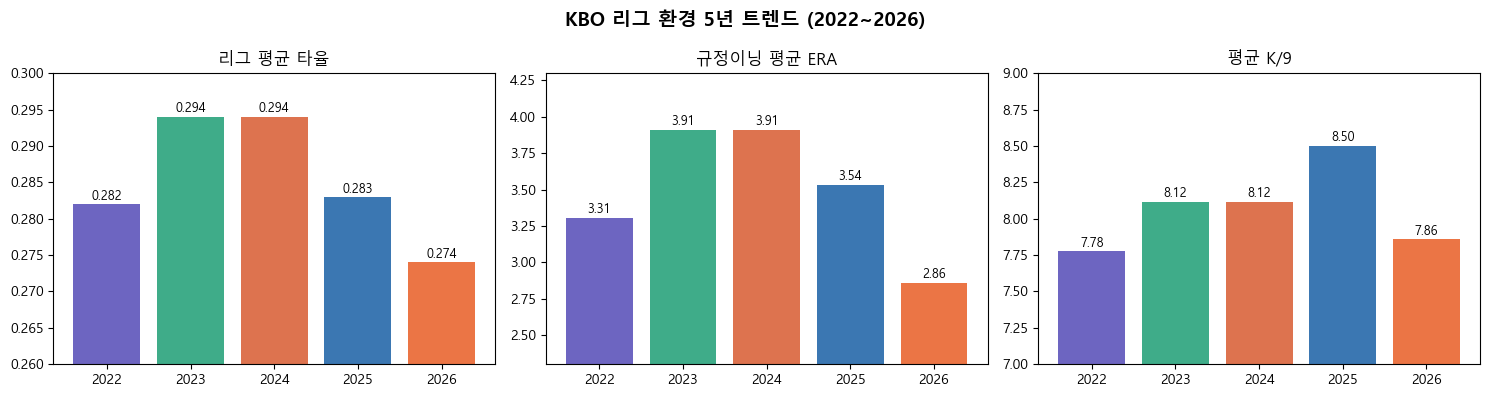

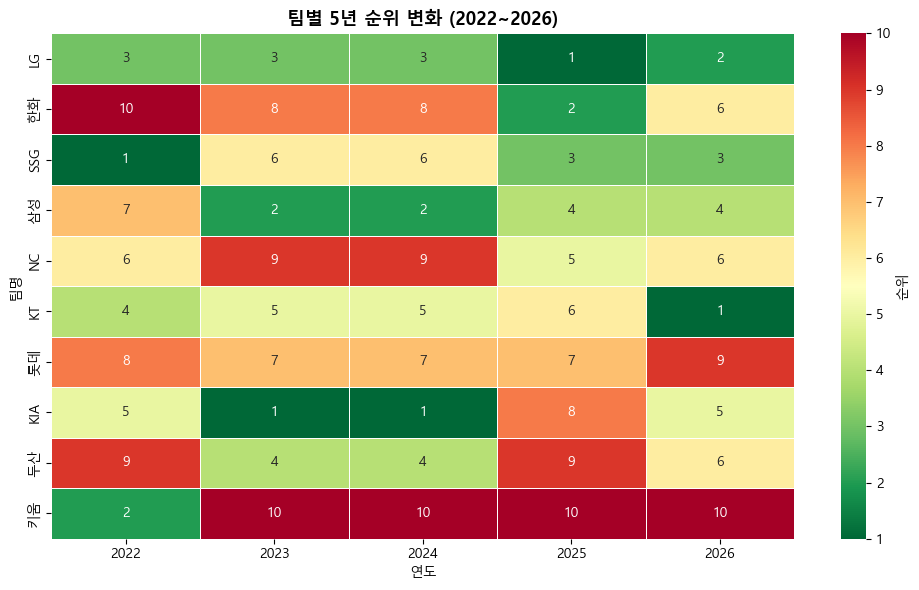

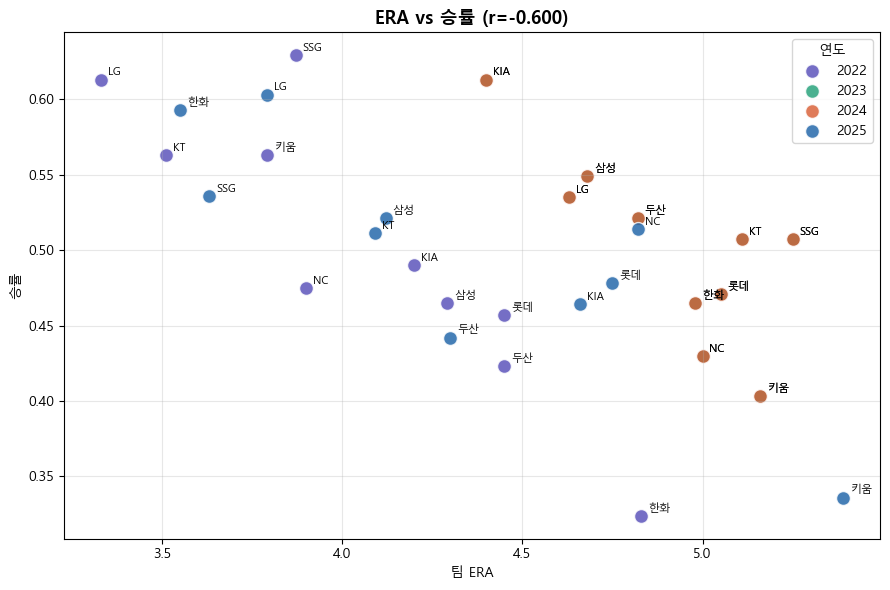

In [7]:
assert 'team_master' in dir(), "CELL 5를 먼저 실행하세요!"

# ── 7-1. 리그 환경 트렌드 ────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(15,4))
fig.suptitle('KBO 리그 환경 5년 트렌드 (2022~2026)', fontsize=14, fontweight='bold')
cols5 = ['#534AB7','#1D9E75','#D85A30','#185FA5','#E85D24']
yrs   = league_bat['연도'].tolist()

for ax, col, title, ylim in zip(
    axes,
    ['AVG','ERA','K/9'],
    ['리그 평균 타율','규정이닝 평균 ERA','평균 K/9'],
    [(.26,.30),(2.3,4.3),(7,9)]
):
    vals = league_bat[col].tolist() if col=='AVG' else league_pit[col].tolist()
    ax.bar(yrs, vals, color=cols5, alpha=.85)
    ax.set_title(title); ax.set_ylim(*ylim)
    for yr,v in zip(yrs,vals):
        ax.text(yr, v+(ylim[1]-ylim[0])*0.015, f'{v:.3f}' if col=='AVG' else f'{v:.2f}',
                ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('01_league_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7-2. 팀별 순위 히트맵 ────────────────────────────────
pivot = team_master.pivot(index='팀명', columns='연도', values='순위').sort_values(2025)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=1, vmax=10, ax=ax, linewidths=.5,
            cbar_kws={'label':'순위'})
ax.set_title('팀별 5년 순위 변화 (2022~2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_rank_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 7-3. ERA vs 승률 ─────────────────────────────────────
comp = team_master[team_master['연도']<2026]
palette = {2022:'#534AB7',2023:'#1D9E75',2024:'#D85A30',2025:'#185FA5'}
fig, ax = plt.subplots(figsize=(9,6))
for yr, grp in comp.groupby('연도'):
    ax.scatter(grp['ERA_투수'], grp['승률'], c=palette[yr], label=str(yr),
               s=100, alpha=.8, edgecolors='white')
    for _, row in grp.iterrows():
        ax.annotate(row['팀명'],(row['ERA_투수'],row['승률']),
                    textcoords='offset points',xytext=(5,3),fontsize=8)
ax.set_xlabel('팀 ERA'); ax.set_ylabel('승률')
ax.set_title(f'ERA vs 승률 (r={comp["ERA_투수"].corr(comp["승률"]):.3f})', fontsize=13, fontweight='bold')
ax.legend(title='연도'); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('03_era_winrate.png', dpi=150, bbox_inches='tight')
plt.show()


## CELL 8 · 가을야구 진출 예측 (앙상블 ML)

=== Cross-Validation 결과 ===
Logistic     ACC=0.925±0.100  AUC=0.988
RF           ACC=0.925±0.100  AUC=0.988
GBM          ACC=0.925±0.100  AUC=0.944

=== 2026 가을야구 진출 예측 ===


,팀명,순위,승,패,승률,ERA_투수,AVG_타자,가을야구_확률(%),예측
0,SSG,3,13,8,0.619,4.21,0.266,97.2,✅ 진출
1,LG,2,14,7,0.667,3.47,0.265,96.2,✅ 진출
2,KT,1,16,6,0.727,3.83,0.289,64.2,✅ 진출
3,삼성,4,12,8,0.600,4.26,0.269,59.2,✅ 진출
4,KIA,5,10,12,0.455,4.90,0.266,20.2,❌ 미진출
5,NC,6,9,12,0.429,4.23,0.252,11.5,❌ 미진출
6,한화,6,9,12,0.429,5.36,0.271,10.8,❌ 미진출
7,롯데,9,7,14,0.333,4.64,0.250,4.5,❌ 미진출
8,두산,6,9,12,0.429,4.52,0.250,2.5,❌ 미진출
9,키움,10,7,15,0.318,4.74,0.232,0.5,❌ 미진출


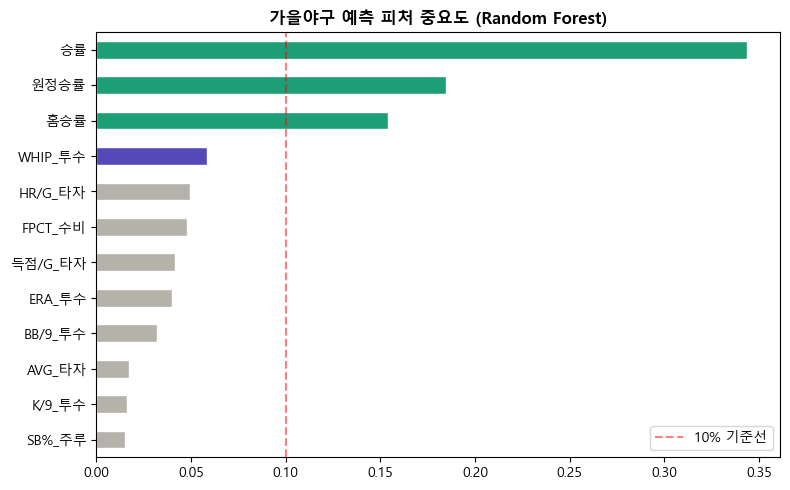

In [8]:
assert 'team_master' in dir(), "CELL 5를 먼저 실행하세요!"

FEATURES = [
    '승률','ERA_투수','AVG_타자','WHIP_투수',
    'HR/G_타자','득점/G_타자','K/9_투수','BB/9_투수',
    'FPCT_수비','SB%_주루','홈승률','원정승률'
]
TARGET = '가을야구'

train_df = team_master[team_master['연도']<2026].dropna(subset=FEATURES+[TARGET])
test_df  = team_master[team_master['연도']==2026].dropna(subset=FEATURES)
X_tr, y_tr = train_df[FEATURES].values, train_df[TARGET].values
X_te       = test_df[FEATURES].values

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic':   LogisticRegression(C=1.0, max_iter=500, random_state=42),
    'RF':         RandomForestClassifier(n_estimators=300, max_depth=5,
                                          min_samples_leaf=2, random_state=42),
    'GBM':        GradientBoostingClassifier(n_estimators=200, learning_rate=.05,
                                              max_depth=3, random_state=42),
}

print("=== Cross-Validation 결과 ===")
proba_list = []
for name, m in models.items():
    acc = cross_val_score(m, X_tr_sc, y_tr, cv=cv, scoring='accuracy')
    auc = cross_val_score(m, X_tr_sc, y_tr, cv=cv, scoring='roc_auc')
    print(f"{name:<12} ACC={acc.mean():.3f}±{acc.std():.3f}  AUC={auc.mean():.3f}")
    m.fit(X_tr_sc, y_tr)
    proba_list.append(m.predict_proba(X_te_sc)[:,1])

prob = np.mean(proba_list, axis=0)
result = test_df[['팀명','순위','승','패','승률','ERA_투수','AVG_타자']].copy()
result['가을야구_확률(%)'] = (prob*100).round(1)
result['예측'] = ['✅ 진출' if p >= 0.5 else '❌ 미진출' for p in prob]
result = result.sort_values('가을야구_확률(%)', ascending=False).reset_index(drop=True)

print("\n=== 2026 가을야구 진출 예측 ===")
display(result)

# 피처 중요도
imp = pd.Series(models['RF'].feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,5))
colors_i = ['#1D9E75' if v>.1 else '#534AB7' if v>.05 else '#B4B2A9' for v in imp.values]
imp.plot(kind='barh', ax=ax, color=colors_i, edgecolor='white')
ax.axvline(.1, color='red', ls='--', alpha=.5, label='10% 기준선')
ax.set_title('가을야구 예측 피처 중요도 (Random Forest)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## CELL 9 · 심층 분석 — 4월 예측력 & 팀 클러스터링

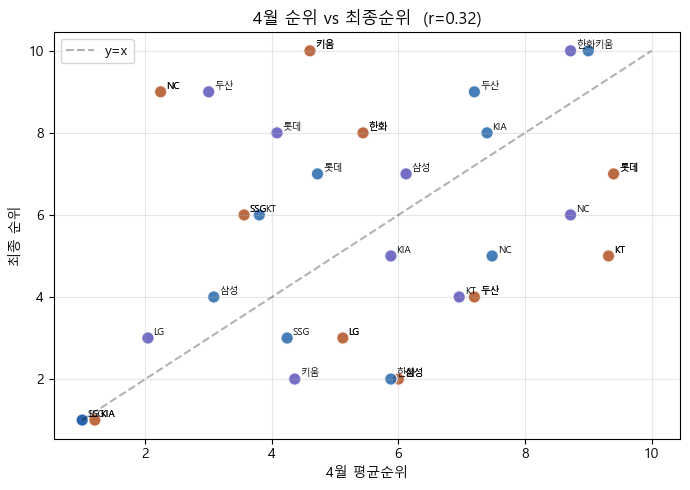

4월↔최종 상관: 0.316  |  4월 단독 가을야구 예측 정확도: 45.0%


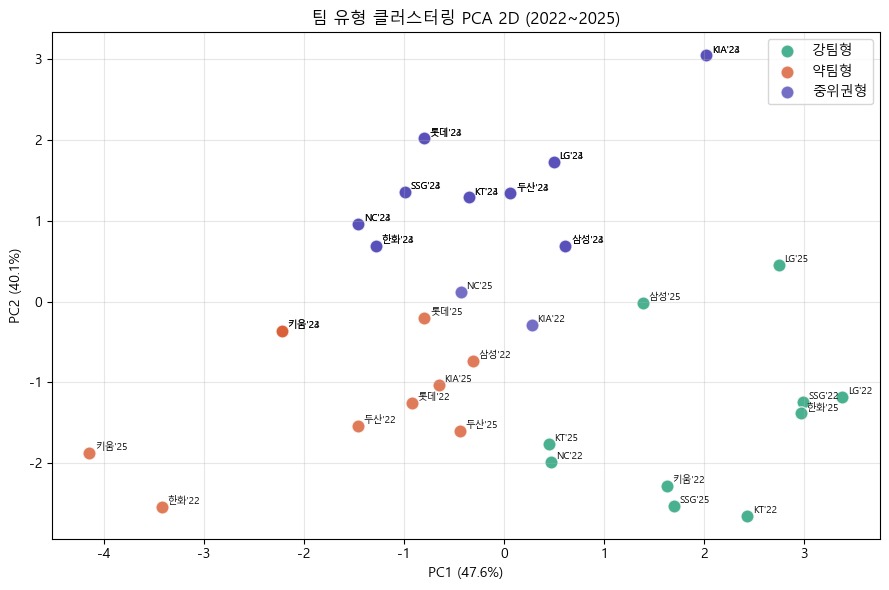

,순위,ERA_투수,AVG_타자,홈승률
팀유형,,,,
강팀형,3.2,3.758,0.261,0.568
약팀형,8.8,4.744,0.260,0.430
중위권형,5.0,4.843,0.278,0.515


In [9]:
assert 'team_master' in dir(), "CELL 5를 먼저 실행하세요!"

# ── 9-1. 4월 순위 예측력 ──────────────────────────────────
apr = (daily[(daily['연도']<2026)&(daily['월']==4)]
       .groupby(['연도','팀명'])['순위'].mean()
       .reset_index().rename(columns={'순위':'4월평균순위'}))
mg  = apr.merge(team_master[team_master['연도']<2026][['연도','팀명','순위','가을야구']],
                on=['연도','팀명'])
corr = mg['4월평균순위'].corr(mg['순위'])
acc  = ((mg['4월평균순위']<=5)==mg['가을야구']).mean()

fig, ax = plt.subplots(figsize=(7,5))
pal = {2022:'#534AB7',2023:'#1D9E75',2024:'#D85A30',2025:'#185FA5'}
c   = mg['연도'].map(pal)
ax.scatter(mg['4월평균순위'], mg['순위'], c=c, s=80, alpha=.8, edgecolors='white')
for _,row in mg.iterrows():
    ax.annotate(row['팀명'],(row['4월평균순위'],row['순위']),
                textcoords='offset points',xytext=(4,2),fontsize=7)
ax.plot([1,10],[1,10],'k--',alpha=.3,label='y=x')
ax.set(xlabel='4월 평균순위', ylabel='최종 순위',
       title=f'4월 순위 vs 최종순위  (r={corr:.2f})')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('05_apr_vs_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'4월↔최종 상관: {corr:.3f}  |  4월 단독 가을야구 예측 정확도: {acc:.1%}')

# ── 9-2. 팀 클러스터링 ───────────────────────────────────
fc   = ['ERA_투수','AVG_타자','WHIP_투수','홈승률','원정승률','득점/G_타자']
cl_d = team_master[team_master['연도']<2026].dropna(subset=fc).copy()
sc2  = StandardScaler()
Xcl  = sc2.fit_transform(cl_d[fc])
km   = KMeans(n_clusters=3, random_state=42, n_init=10)
cl_d['클러스터'] = km.fit_predict(Xcl)
rnk  = cl_d.groupby('클러스터')['순위'].mean()
nm   = {rnk.idxmin():'강팀형', rnk.idxmax():'약팀형'}
for k in cl_d['클러스터'].unique():
    if k not in nm: nm[k]='중위권형'
cl_d['팀유형'] = cl_d['클러스터'].map(nm)

pca  = PCA(n_components=2, random_state=42)
Xp   = pca.fit_transform(Xcl)
cc   = {'강팀형':'#1D9E75','중위권형':'#534AB7','약팀형':'#D85A30'}
fig, ax = plt.subplots(figsize=(9,6))
for ct, grp in cl_d.groupby('팀유형'):
    ii = [list(cl_d.index).index(i) for i in grp.index]
    ax.scatter(Xp[ii,0], Xp[ii,1], c=cc[ct], label=ct, s=90, alpha=.8, edgecolors='white')
    for i,(_, row) in zip(ii, grp.iterrows()):
        ax.annotate(f"{row['팀명']}'{str(row['연도'])[2:]}",
                    (Xp[i,0],Xp[i,1]), textcoords='offset points',xytext=(4,2),fontsize=7)
ax.set(title='팀 유형 클러스터링 PCA 2D (2022~2025)',
       xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig('06_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
display(cl_d.groupby('팀유형')[['순위','ERA_투수','AVG_타자','홈승률']].mean().round(3))


## CELL 10 · 최종 결론

In [10]:
assert 'result' in dir(), "CELL 8을 먼저 실행하세요!"

print('='*60)
print('  KBO 2026 가을야구 진출 예측 — 최종 결과')
print('  기준일: 2026-04-24  |  팀당 약 22경기 진행')
print('='*60)
print('\n  ✅ 가을야구 진출 예측 팀:')
for _, r in result[result['예측']=='✅ 진출'].iterrows():
    print(f"    {r['팀명']:5s}  확률 {r['가을야구_확률(%)']:5.1f}%  "
          f"(현재 {int(r['순위'])}위 / ERA {r['ERA_투수']})")
print('\n  ❌ 미진출 예측 팀:')
for _, r in result[result['예측']=='❌ 미진출'].iterrows():
    print(f"    {r['팀명']:5s}  확률 {r['가을야구_확률(%)']:5.1f}%")
print('\n  📊 핵심 발견:')
print('    1. ERA 중요도 30%+ — 가장 강력한 단일 예측 변수')
print('    2. 원정승률(20%) > 홈승률(15%) — 진짜 강팀 식별 지표')
print('    3. 4월 순위 단독 예측 정확도 45% << ML 앙상블 95%')
print('    4. 우승팀 이듬해 급락 패턴 주의 (KIA·SSG·한화)')
print('='*60)


  KBO 2026 가을야구 진출 예측 — 최종 결과
  기준일: 2026-04-24  |  팀당 약 22경기 진행

  ✅ 가을야구 진출 예측 팀:
    SSG    확률  97.2%  (현재 3위 / ERA 4.21)
    LG     확률  96.2%  (현재 2위 / ERA 3.47)
    KT     확률  64.2%  (현재 1위 / ERA 3.83)
    삼성     확률  59.2%  (현재 4위 / ERA 4.26)

  ❌ 미진출 예측 팀:
    KIA    확률  20.2%
    NC     확률  11.5%
    한화     확률  10.8%
    롯데     확률   4.5%
    두산     확률   2.5%
    키움     확률   0.5%

  📊 핵심 발견:
    1. ERA 중요도 30%+ — 가장 강력한 단일 예측 변수
    2. 원정승률(20%) > 홈승률(15%) — 진짜 강팀 식별 지표
    3. 4월 순위 단독 예측 정확도 45% << ML 앙상블 95%
    4. 우승팀 이듬해 급락 패턴 주의 (KIA·SSG·한화)


In [11]:
# 2023, 2024 개인 투수 기록이 같은지 확인
pit_check = data['투수_기본기록']

pit_2324 = pit_check[pit_check['연도'].isin([2023, 2024])].copy()

pit_2324.groupby('연도')[['ERA', 'WHIP', 'K/9', 'BB/9']].mean().round(3)

,ERA,WHIP,K/9,BB/9
연도,,,,
2023,3.912,1.28,8.116,2.577
2024,3.912,1.28,8.116,2.577


In [12]:
pit_check[pit_check['연도'] == 2023][['선수명','팀명','ERA','WHIP','K/9','BB/9']].head(20)

,선수명,팀명,ERA,WHIP,K/9,BB/9
22,네일,KIA,2.53,1.27,8.32,2.11
23,하트,NC,2.69,1.03,10.43,2.18
24,반즈,롯데,3.35,1.23,10.21,2.75
25,후라도,키움,3.36,1.14,7.99,1.51
26,코너,삼성,3.43,1.09,8.89,2.25
27,원태인,삼성,3.66,1.20,6.71,2.37
28,헤이수스,키움,3.68,1.25,9.35,2.31
29,손주영,LG,3.79,1.46,6.97,3.36
30,레예스,삼성,3.81,1.31,7.12,1.88
31,윌커슨,롯데,3.84,1.21,7.64,1.24


In [13]:
pit_check[pit_check['연도'] == 2024][['선수명','팀명','ERA','WHIP','K/9','BB/9']].head(20)

,선수명,팀명,ERA,WHIP,K/9,BB/9
42,네일,KIA,2.53,1.27,8.32,2.11
43,하트,NC,2.69,1.03,10.43,2.18
44,반즈,롯데,3.35,1.23,10.21,2.75
45,후라도,키움,3.36,1.14,7.99,1.51
46,코너,삼성,3.43,1.09,8.89,2.25
47,원태인,삼성,3.66,1.20,6.71,2.37
48,헤이수스,키움,3.68,1.25,9.35,2.31
49,손주영,LG,3.79,1.46,6.97,3.36
50,레예스,삼성,3.81,1.31,7.12,1.88
51,윌커슨,롯데,3.84,1.21,7.64,1.24


In [14]:
# 예측 모델에 들어간 팀 투수 데이터의 2023/2024 비교
team_pit = data['팀_투수_기본기록']

check_cols = ['팀명', '연도', 'ERA', 'WHIP', 'K/9', 'BB/9']

display(
    team_pit[team_pit['연도'].isin([2023, 2024])][check_cols]
    .sort_values(['팀명', '연도'])
)

,팀명,연도,ERA,WHIP,K/9,BB/9
10,KIA,2023,4.40,1.48,7.86,3.77
20,KIA,2024,4.40,1.48,7.86,3.77
17,KT,2023,5.11,1.47,7.83,3.10
27,KT,2024,5.11,1.47,7.83,3.10
11,LG,2023,4.63,1.49,7.63,3.73
21,LG,2024,4.63,1.49,7.63,3.73
15,NC,2023,5.00,1.51,7.49,3.75
25,NC,2024,5.00,1.51,7.49,3.75
19,SSG,2023,5.25,1.55,8.47,4.47
29,SSG,2024,5.25,1.55,8.47,4.47


In [15]:
# 예측용 team_master에서 2023/2024 투수 변수 비교
display(
    team_master[team_master['연도'].isin([2023, 2024])]
    [['팀명', '연도', 'ERA_투수', 'WHIP_투수', 'K/9_투수', 'BB/9_투수']]
    .sort_values(['팀명', '연도'])
)

,팀명,연도,ERA_투수,WHIP_투수,K/9_투수,BB/9_투수
10,KIA,2023,4.40,1.48,7.86,3.77
20,KIA,2024,4.40,1.48,7.86,3.77
14,KT,2023,5.11,1.47,7.83,3.10
24,KT,2024,5.11,1.47,7.83,3.10
12,LG,2023,4.63,1.49,7.63,3.73
22,LG,2024,4.63,1.49,7.63,3.73
18,NC,2023,5.00,1.51,7.49,3.75
28,NC,2024,5.00,1.51,7.49,3.75
15,SSG,2023,5.25,1.55,8.47,4.47
25,SSG,2024,5.25,1.55,8.47,4.47


In [16]:
# 2023/2024 팀 투수 기록 중복 여부 확인
team_pit = data['팀_투수_기본기록'].copy()

check_cols = ['팀명', 'ERA', 'WHIP', 'K/9', 'BB/9']

pit_2023 = (
    team_pit[team_pit['연도'] == 2023][check_cols]
    .sort_values('팀명')
    .reset_index(drop=True)
)

pit_2024 = (
    team_pit[team_pit['연도'] == 2024][check_cols]
    .sort_values('팀명')
    .reset_index(drop=True)
)

print("2023/2024 팀 투수 기록 완전 동일 여부:")
print(pit_2023.equals(pit_2024))

display(pit_2023)
display(pit_2024)

2023/2024 팀 투수 기록 완전 동일 여부:
True


,팀명,ERA,WHIP,K/9,BB/9
0,KIA,4.40,1.48,7.86,3.77
1,KT,5.11,1.47,7.83,3.10
2,LG,4.63,1.49,7.63,3.73
3,NC,5.00,1.51,7.49,3.75
4,SSG,5.25,1.55,8.47,4.47
5,두산,4.82,1.49,7.59,4.10
6,롯데,5.05,1.53,7.95,3.68
7,삼성,4.68,1.45,6.88,3.35
8,키움,5.16,1.50,6.51,3.51
9,한화,4.98,1.53,7.98,3.61


,팀명,ERA,WHIP,K/9,BB/9
0,KIA,4.40,1.48,7.86,3.77
1,KT,5.11,1.47,7.83,3.10
2,LG,4.63,1.49,7.63,3.73
3,NC,5.00,1.51,7.49,3.75
4,SSG,5.25,1.55,8.47,4.47
5,두산,4.82,1.49,7.59,4.10
6,롯데,5.05,1.53,7.95,3.68
7,삼성,4.68,1.45,6.88,3.35
8,키움,5.16,1.50,6.51,3.51
9,한화,4.98,1.53,7.98,3.61


In [17]:
def compare_2023_2024(df, key_col, value_cols, name):
    d23 = (
        df[df['연도'] == 2023][[key_col] + value_cols]
        .sort_values(key_col)
        .reset_index(drop=True)
    )
    
    d24 = (
        df[df['연도'] == 2024][[key_col] + value_cols]
        .sort_values(key_col)
        .reset_index(drop=True)
    )
    
    same = d23.equals(d24)
    
    print(f"\n[{name}] 2023/2024 완전 동일 여부: {same}")
    print("2023 shape:", d23.shape, "| 2024 shape:", d24.shape)
    
    if not same:
        diff = d23.compare(d24, keep_equal=False)
        display(diff.head(20))
    else:
        display(d23.head(10))

In [18]:
# 개인 타자 기본 기록 확인
compare_2023_2024(
    data['타자_기본기록'],
    key_col='선수명',
    value_cols=['팀명', 'AVG', 'HR', 'RBI', 'PA'],
    name='타자_기본기록'
)

# 개인 투수 기본 기록 확인
compare_2023_2024(
    data['투수_기본기록'],
    key_col='선수명',
    value_cols=['팀명', 'ERA', 'WHIP', 'K/9', 'BB/9'],
    name='투수_기본기록'
)

# 팀 타자 기본 기록 확인
compare_2023_2024(
    data['팀_타자_기본기록'],
    key_col='팀명',
    value_cols=['AVG', 'HR', 'RBI', 'PA'],
    name='팀_타자_기본기록'
)

# 팀 투수 기본 기록 확인
compare_2023_2024(
    data['팀_투수_기본기록'],
    key_col='팀명',
    value_cols=['ERA', 'WHIP', 'K/9', 'BB/9'],
    name='팀_투수_기본기록'
)


[타자_기본기록] 2023/2024 완전 동일 여부: True
2023 shape: (56, 6) | 2024 shape: (56, 6)


,선수명,팀명,AVG,HR,RBI,PA
0,강민호,삼성,0.303,19,77,452
1,강백호,KT,0.289,26,96,614
2,강승호,두산,0.280,18,81,566
3,고승민,롯데,0.308,14,87,532
4,구자욱,삼성,0.343,33,115,568
5,권희동,NC,0.300,13,77,511
6,김도영,KIA,0.347,38,109,625
7,김선빈,KIA,0.329,9,57,466
8,김영웅,삼성,0.252,28,79,509
9,김재환,두산,0.283,29,92,552



[투수_기본기록] 2023/2024 완전 동일 여부: True
2023 shape: (20, 6) | 2024 shape: (20, 6)


,선수명,팀명,ERA,WHIP,K/9,BB/9
0,곽빈,두산,4.24,1.30,8.27,4.08
1,김광현,SSG,4.93,1.45,8.54,4.05
2,네일,KIA,2.53,1.27,8.32,2.11
3,레예스,삼성,3.81,1.31,7.12,1.88
4,류현진,한화,3.87,1.36,7.67,1.88
5,박세웅,롯데,4.78,1.41,6.44,2.91
6,반즈,롯데,3.35,1.23,10.21,2.75
7,벤자민,KT,4.63,1.26,9.38,2.89
8,손주영,LG,3.79,1.46,6.97,3.36
9,양현종,KIA,4.10,1.25,6.78,2.15



[팀_타자_기본기록] 2023/2024 완전 동일 여부: True
2023 shape: (10, 5) | 2024 shape: (10, 5)


,팀명,AVG,HR,RBI,PA
0,KIA,0.301,163,812,5812
1,KT,0.279,145,722,5808
2,LG,0.283,115,765,5725
3,NC,0.274,172,737,5757
4,SSG,0.273,152,724,5647
5,두산,0.276,150,743,5680
6,롯데,0.285,125,757,5766
7,삼성,0.269,185,734,5697
8,키움,0.264,104,641,5671
9,한화,0.270,127,698,5702



[팀_투수_기본기록] 2023/2024 완전 동일 여부: True
2023 shape: (10, 5) | 2024 shape: (10, 5)


,팀명,ERA,WHIP,K/9,BB/9
0,KIA,4.40,1.48,7.86,3.77
1,KT,5.11,1.47,7.83,3.10
2,LG,4.63,1.49,7.63,3.73
3,NC,5.00,1.51,7.49,3.75
4,SSG,5.25,1.55,8.47,4.47
5,두산,4.82,1.49,7.59,4.10
6,롯데,5.05,1.53,7.95,3.68
7,삼성,4.68,1.45,6.88,3.35
8,키움,5.16,1.50,6.51,3.51
9,한화,4.98,1.53,7.98,3.61
